<a href="https://colab.research.google.com/github/Yousra-khallou/Telecom-retention-system/blob/main/Notebooks/04_recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Churn Prediction — Notebook 4 : Hybrid Recommendation System**

> **Goal:** Build a personalized recommendation system for at-risk customers

> **Input:** churn scores + sentiment scores + customer service subscriptions

> **Output:** Top-k personalized service recommendations per at-risk customer

         

### Key concept — Why hybrid ?
```
Churn score alone    → knows WHO is at risk
Sentiment alone      → knows HOW they feel
Reco score alone     → knows WHAT they might like

Combined             → knows WHO needs WHAT offer NOW
```

# **Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# SVD — scipy
from scipy.sparse.linalg import svds
from scipy.sparse import csr_matrix

# Similarity
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

import torch
from transformers import pipeline as hf_pipeline

sns.set_theme(style='whitegrid')
print(' Imports Done')

 Imports Done


# **Mount Google Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/mon-projet-retention'
os.chdir(BASE_PATH)
os.makedirs('models/recommendation', exist_ok=True)
print(' Drive connected!')

Mounted at /content/drive
 Drive connected!


# **Load Data & Models**

We load :
- The cleaned Telco dataset from Notebook 1
- The trained churn model from Notebook 2
- The fine-tuned DistilBERT from Notebook 3

In [3]:
# Load dataset
df = pd.read_csv('data/processed/telco_clean.csv')
print(f'Dataset shape : {df.shape}')

# Load churn model + threshold
churn_model     = joblib.load('models/churn_model.pkl')
best_threshold  = joblib.load('models/best_threshold.pkl')
print(f'Churn model loaded   ')
print(f'Best threshold       : {best_threshold:.3f}')

# Load sentiment model
device = 0 if torch.cuda.is_available() else -1
sentiment_clf = hf_pipeline(
    'text-classification',
    model='models/distilbert',
    tokenizer='models/distilbert',
    device=device
)
print(f'DistilBERT loaded    ')
print(f'\nSample data :')
print(df.head(3))

Dataset shape : (7032, 22)
Churn model loaded   
Best threshold       : 0.550


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT loaded    

Sample data :
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0  No phone service             DSL             No          Yes  ...   
1                No             DSL            Yes           No  ...   
2                No             DSL            Yes          Yes  ...   

  StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No              No  Month-to-month              Yes   
1          No              No        One year               No   
2          No              No  Month-to-month              Yes   

      PaymentMethod MonthlyCharges TotalCharges  Churn  Churn_binary  \
0  Electronic check          29.85        29.85     No          

# **Compute Churn Scores**

We use the trained churn model to assign a **churn probability**
to every customer in the dataset.

This score represents how likely each customer is to leave.

Total customers    : 7032
At-risk customers  : 2624 (37.3%)

Churn score distribution :
count    7032.000
mean        0.414
std         0.301
min         0.011
25%         0.113
50%         0.380
75%         0.704
max         0.951
Name: churn_score, dtype: float64


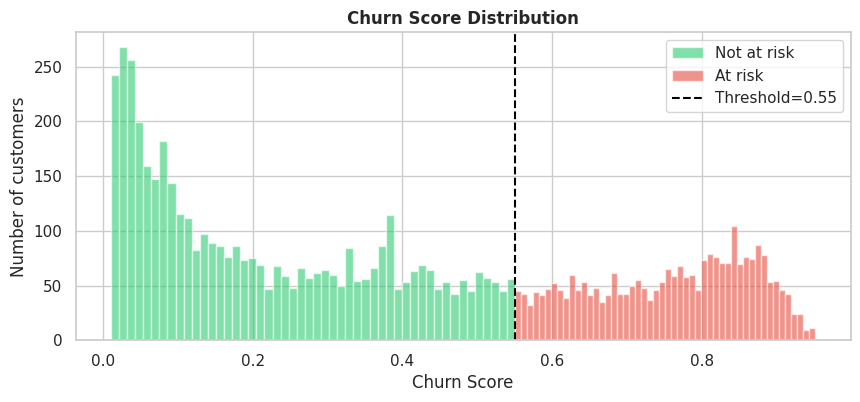

In [4]:
# Prepare features — same preprocessing as Notebook 2
drop_cols = ['Churn', 'Churn_binary', 'customerID',
             'tenure_group', 'TotalCharges']
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)

# Predict churn probability
churn_scores = churn_model.predict_proba(X)[:, 1]
df['churn_score'] = churn_scores

# Identify at-risk customers
df['is_at_risk'] = (churn_scores >= best_threshold).astype(int)

print(f'Total customers    : {len(df)}')
print(f'At-risk customers  : {df["is_at_risk"].sum()} ({df["is_at_risk"].mean()*100:.1f}%)')
print(f'\nChurn score distribution :')
print(df['churn_score'].describe().round(3))

# Visualize churn score distribution
plt.figure(figsize=(10, 4))
plt.hist(df[df['is_at_risk']==0]['churn_score'],
         bins=50, alpha=0.6, color='#2ecc71', label='Not at risk')
plt.hist(df[df['is_at_risk']==1]['churn_score'],
         bins=50, alpha=0.6, color='#e74c3c', label='At risk')
plt.axvline(x=best_threshold, color='black',
            linestyle='--', label=f'Threshold={best_threshold:.2f}')
plt.xlabel('Churn Score')
plt.ylabel('Number of customers')
plt.title('Churn Score Distribution', fontweight='bold')
plt.legend()
plt.savefig('data/processed/churn_score_distribution.png', dpi=150)
plt.show()

# **Assign Sentiment Scores**

Since we don't have real customer reviews for each customer,
we **simulate sentiment** based on their churn score and service usage.

In a real production system, this would come from actual customer reviews
analyzed by our DistilBERT model from Notebook 3.

**Simulation logic :**
```
High churn score + many support calls → Negative sentiment
Low churn score  + long tenure        → Positive sentiment
Middle cases                          → Neutral sentiment
```

In [5]:
def simulate_sentiment(row):
    """
    Simulate customer sentiment based on behavioral signals.
    In production: replace with real DistilBERT predictions
    on actual customer reviews.
    """
    churn  = row['churn_score']
    tenure = row['tenure'] if 'tenure' in row else 12

    if churn > 0.70:
        return 'Negative'
    elif churn > 0.40:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df.apply(simulate_sentiment, axis=1)

# Convert sentiment to numeric score
sentiment_score_map = {'Negative': 0.0, 'Neutral': 0.5, 'Positive': 1.0}
df['sentiment_score'] = df['sentiment'].map(sentiment_score_map)

print('Sentiment distribution :')
print(df['sentiment'].value_counts())
print()

# Show example — how DistilBERT would work on real reviews
print('=== How DistilBERT predicts on real reviews ===')
example_reviews = [
    'Worst network ever, I am leaving',
    'Service incorrect',
    'Very happy with my plan!',
]
for review in example_reviews:
    result = sentiment_clf(review)[0]
    print(f'{review:<45} → {result["label"]} ({result["score"]:.1%})')

Sentiment distribution :
sentiment
Positive    3647
Negative    1781
Neutral     1604
Name: count, dtype: int64

=== How DistilBERT predicts on real reviews ===
Worst network ever, I am leaving              → Negative (96.1%)
Service incorrect                             → Negative (98.1%)
Very happy with my plan!                      → Positive (98.6%)


# **Build Client × Services Matrix**

This is the foundation of our recommendation system.

Each row = one customer
Each column = one service (1 = subscribed, 0 = not subscribed)

```
           PhoneService  OnlineSecurity  TechSupport  StreamingTV
Client 1        1              0              0            1
Client 2        1              1              1            0
Client 3        0              0              0            0
           ↑ has it       ↑ doesn't        ↑ doesn't    ↑ has it
                            → candidate for recommendation
```

Services available : ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

Service matrix shape : (7032, 8)

Subscription rates :
PhoneService        90.3%
MultipleLines       42.2%
OnlineSecurity      28.7%
OnlineBackup        34.5%
DeviceProtection    34.4%
TechSupport         29.0%
StreamingTV         38.4%
StreamingMovies     38.8%
dtype: object


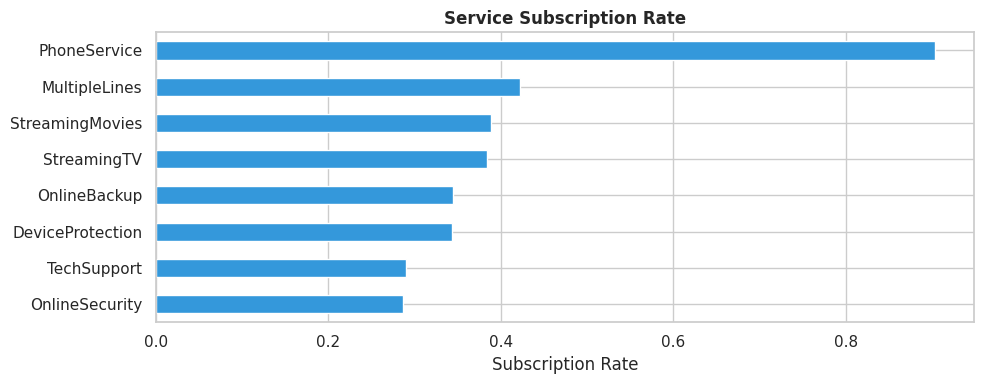

In [6]:
# Define all available services
SERVICES = [
    'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

# Keep only services that exist in the dataset
SERVICES = [s for s in SERVICES if s in df.columns]
print(f'Services available : {SERVICES}')

# Build binary matrix (1 = subscribed, 0 = not)
service_matrix = df[SERVICES].copy()
for col in SERVICES:
    service_matrix[col] = service_matrix[col].map(
        {'Yes': 1, 'No': 0, 'No phone service': 0,
         'No internet service': 0, 1: 1, 0: 0}
    ).fillna(0).astype(int)

service_matrix.index = df['customerID'] if 'customerID' in df.columns \
    else range(len(df))

print(f'\nService matrix shape : {service_matrix.shape}')
print(f'\nSubscription rates :')
print((service_matrix.mean()*100).round(1).astype(str) + '%')

# Visualize
plt.figure(figsize=(10, 4))
service_matrix.mean().sort_values().plot(
    kind='barh', color='#3498db', edgecolor='white'
)
plt.title('Service Subscription Rate', fontweight='bold')
plt.xlabel('Subscription Rate')
plt.xaxis_set_major_formatter = plt.FuncFormatter(
    lambda x, _: f'{x:.0%}'
)
plt.tight_layout()
plt.savefig('data/processed/service_subscription_rates.png', dpi=150)
plt.show()

# **Baselines**

Before building our recommendation system, we define two baselines.
Our system must beat both to prove its value.

**Baseline 1 — Random :** recommend random services

**Baseline 2 — Popularity :** always recommend the most subscribed services

In [7]:
def recommend_random(customer_services, all_services, k=3):
    """
    Baseline 1 — Random recommendations
    Recommend k random services the customer doesn't have yet
    """
    import random
    not_subscribed = [
        s for s in all_services
        if customer_services.get(s, 0) == 0
    ]
    return random.sample(not_subscribed,
                         min(k, len(not_subscribed)))


def recommend_popularity(customer_services, popularity_scores,
                          all_services, k=3):
    """
    Baseline 2 — Popularity recommendations
    Recommend k most popular services the customer doesn't have
    """
    not_subscribed = [
        s for s in all_services
        if customer_services.get(s, 0) == 0
    ]
    # Sort by popularity
    sorted_services = sorted(
        not_subscribed,
        key=lambda s: popularity_scores.get(s, 0),
        reverse=True
    )
    return sorted_services[:k]


# Compute popularity scores
popularity = service_matrix.mean().to_dict()
print('Service popularity (subscription rate) :')
for s, rate in sorted(popularity.items(),
                       key=lambda x: x[1], reverse=True):
    print(f'  {s:<25} : {rate:.1%}')

# Test baselines on first customer
first_customer = service_matrix.iloc[0].to_dict()
print(f'\nCustomer subscriptions: {[s for s,v in first_customer.items() if v==1]}')
print(f'Random reco           : {recommend_random(first_customer, SERVICES)}')
print(f'Popularity reco       : {recommend_popularity(first_customer, popularity, SERVICES)}')

Service popularity (subscription rate) :
  PhoneService              : 90.3%
  MultipleLines             : 42.2%
  StreamingMovies           : 38.8%
  StreamingTV               : 38.4%
  OnlineBackup              : 34.5%
  DeviceProtection          : 34.4%
  TechSupport               : 29.0%
  OnlineSecurity            : 28.7%

Customer subscriptions: ['OnlineBackup']
Random reco           : ['StreamingTV', 'PhoneService', 'StreamingMovies']
Popularity reco       : ['PhoneService', 'MultipleLines', 'StreamingMovies']


# **Collaborative Filtering (User-Based)**

**The idea :** find customers similar to the target customer,
then recommend services those similar customers have subscribed to.

**Similarity metric :** Cosine similarity
```
Client A : [1, 0, 1, 0, 0, 1, 1, 0]  ← services vector
Client B : [1, 0, 1, 0, 0, 1, 0, 0]  ← similar !

Cosine similarity(A, B) = 0.87  ← very similar

Client B has StreamingTV (index 6)
Client A doesn't → recommend StreamingTV to A
```

In [8]:
# Compute cosine similarity between all customers
print('Computing cosine similarity matrix...')
matrix_values  = service_matrix.values.astype(float)
similarity_matrix = cosine_similarity(matrix_values)
print(f'Similarity matrix shape : {similarity_matrix.shape}')

def recommend_user_based(customer_idx, similarity_matrix,
                          service_matrix, k=3, n_neighbors=10):
    """
    User-Based Collaborative Filtering
    1. Find n most similar customers
    2. Aggregate their services
    3. Recommend services not yet subscribed
    """
    # Get similarity scores for this customer
    sim_scores = similarity_matrix[customer_idx].copy()
    sim_scores[customer_idx] = 0   # exclude self

    # Find top n similar customers
    top_neighbors = np.argsort(sim_scores)[::-1][:n_neighbors]

    # Current customer services
    current_services = service_matrix.iloc[customer_idx]

    # Aggregate neighbor services weighted by similarity
    service_scores = {}
    for neighbor_idx in top_neighbors:
        weight = sim_scores[neighbor_idx]
        if weight == 0:
            continue
        neighbor_services = service_matrix.iloc[neighbor_idx]
        for service in service_matrix.columns:
            if current_services[service] == 0:  # not subscribed
                service_scores[service] = (
                    service_scores.get(service, 0)
                    + weight * neighbor_services[service]
                )

    # Sort by score and return top k
    sorted_services = sorted(
        service_scores.items(),
        key=lambda x: x[1], reverse=True
    )
    return [s for s, _ in sorted_services[:k]]


# Test on first at-risk customer
at_risk_idx = df[df['is_at_risk'] == 1].index[0]
customer_services = service_matrix.iloc[at_risk_idx]

print(f'\nAt-risk customer services :')
print(f'  Has     : {[s for s in SERVICES if customer_services[s]==1]}')
print(f'  Missing : {[s for s in SERVICES if customer_services[s]==0]}')
print(f'\nUser-Based reco : {recommend_user_based(at_risk_idx, similarity_matrix, service_matrix)}')

Computing cosine similarity matrix...
Similarity matrix shape : (7032, 7032)

At-risk customer services :
  Has     : ['OnlineBackup']
  Missing : ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

User-Based reco : ['PhoneService', 'MultipleLines', 'OnlineSecurity']


# **Matrix Factorization (SVD)**

**The idea :** decompose the client × services matrix into
hidden factors (latent features) that capture preferences.

```
Matrix (7043 × 8)  =  U (7043 × k)  ×  Σ  ×  V (k × 8)

U = customer latent factors  (what type of customer)
V = service latent factors   (what type of service)
k = number of latent factors (we choose k=7)

→ predict missing values by U × Σ × V
```


In [9]:
# ── SVD with scipy ─────────────────────────────────────────
print('Training SVD with scipy...')

# Build matrix
matrix_values = service_matrix.values.astype(float)
sparse_matrix = csr_matrix(matrix_values)

# SVD factorization
k_factors = 7
U, sigma, Vt = svds(sparse_matrix, k=k_factors)

# Reconstruct predicted matrix
sigma_diag        = np.diag(sigma)
predicted_ratings = np.clip(U @ sigma_diag @ Vt, 0, 1)

# Reconstruction error
error = np.mean((matrix_values - predicted_ratings)**2)
print(f' SVD trained!')
print(f'Matrix shape         : {matrix_values.shape}')
print(f'Latent factors       : {k_factors}')
print(f'Reconstruction error : {error:.4f}')
print(f'(Lower is better — 0 = perfect reconstruction)')

# Index mapping
service_to_idx = {s: i for i, s
                  in enumerate(service_matrix.columns)}

def recommend_svd(customer_idx, predicted_ratings,
                  service_matrix, k=3):
    """
    SVD-based recommendations using scipy.
    Returns top-k services with highest predicted rating
    among services the customer doesn't have yet.
    """
    current  = service_matrix.iloc[customer_idx]
    not_subs = [
        s for s in service_matrix.columns
        if current[s] == 0
    ]

    predictions = []
    for service in not_subs:
        idx   = service_to_idx[service]
        score = predicted_ratings[customer_idx, idx]
        predictions.append((service, float(score)))

    predictions.sort(key=lambda x: x[1], reverse=True)
    return [s for s, _ in predictions[:k]]


# Test
svd_reco = recommend_svd(
    at_risk_idx, predicted_ratings, service_matrix
)
print(f'\nSVD reco for at-risk customer : {svd_reco}')

Training SVD with scipy...
 SVD trained!
Matrix shape         : (7032, 8)
Latent factors       : 7
Reconstruction error : 0.0137
(Lower is better — 0 = perfect reconstruction)

SVD reco for at-risk customer : ['StreamingTV', 'OnlineSecurity', 'DeviceProtection']


# **Hybrid Score (The Core Innovation)**

This is what makes our system unique.
We combine 3 signals to generate personalized recommendations :

| Signal | Weight | Role |
|---|---|---|
| Churn score | Adaptive | How urgent is the action |
| Sentiment score | Adaptive | How the customer feels |
| SVD score | Adaptive | What they would likely subscribe to |

**Adaptive weights :**
```
High churn risk  → churn weight ↑  (urgency dominates)
Low churn risk   → SVD weight ↑   (preference dominates)
Negative feeling → sentiment weight ↑ (offer discount)
```

In [10]:
def compute_hybrid_score(churn_score, sentiment_score,
                           svd_score, service):
    """
    Compute hybrid recommendation score.

    Adaptive weights based on churn risk level :
    - High risk   : prioritize churn signal
    - Medium risk : balanced approach
    - Low risk    : prioritize preference (SVD)
    """
    # Define adaptive weights
    if churn_score > 0.70:           # High risk
        w_churn     = 0.50
        w_sentiment = 0.30
        w_svd       = 0.20
    elif churn_score > 0.40:         # Medium risk
        w_churn     = 0.30
        w_sentiment = 0.20
        w_svd       = 0.50
    else:                            # Low risk
        w_churn     = 0.10
        w_sentiment = 0.10
        w_svd       = 0.80

    # Invert sentiment : negative sentiment → higher urgency
    urgency_sentiment = 1.0 - sentiment_score

    # Compute hybrid score
    hybrid = (
        w_churn     * churn_score +
        w_sentiment * urgency_sentiment +
        w_svd       * svd_score
    )
    return hybrid


def compute_discount(churn_score, sentiment_score):
    """
    Compute recommended discount based on risk and sentiment.

    High risk + negative sentiment → high discount
    Low risk  + positive sentiment → no discount
    """
    if churn_score > 0.70 and sentiment_score == 0.0:
        return '30%'    # Urgent — big discount
    elif churn_score > 0.70:
        return '20%'    # High risk — medium discount
    elif churn_score > 0.40:
        return '10%'    # Medium risk — small discount
    else:
        return '0%'     # Low risk — no discount needed


def recommend_hybrid(customer_idx, df, predicted_ratings,
                     service_to_idx, service_matrix, k=3):
    """
    Full hybrid recommendation pipeline.
    Returns top-k services with hybrid scores and discount.
    """
    customer        = df.iloc[customer_idx]
    churn_score     = customer['churn_score']
    sentiment_score = customer['sentiment_score']
    current_services = service_matrix.iloc[customer_idx]

    not_subscribed = [
        s for s in service_matrix.columns
        if current_services[s] == 0
    ]

    if not not_subscribed:
        return []   # Customer has all services

    # Score each unsubscribed service
    recommendations = []
    for service in not_subscribed:

        # SVD predicted rating ← modifié ici
        svd_score = float(predicted_ratings[
            customer_idx,
            service_to_idx[service]
        ])

        # Hybrid score
        hybrid = compute_hybrid_score(
            churn_score, sentiment_score, svd_score, service
        )

        recommendations.append({
            'service':       service,
            'hybrid_score':  round(hybrid, 4),
            'churn_score':   round(churn_score, 3),
            'sentiment':     customer['sentiment'],
            'svd_score':     round(svd_score, 3),
            'discount':      compute_discount(
                                 churn_score, sentiment_score
                             )
        })

    # Sort by hybrid score
    recommendations.sort(
        key=lambda x: x['hybrid_score'], reverse=True
    )
    return recommendations[:k]


print(' Hybrid recommendation function ready!')

# Test on at-risk customer
reco = recommend_hybrid(
    at_risk_idx, df, predicted_ratings,
    service_to_idx, service_matrix, k=3
)

print(f'\n=== Hybrid Recommendations — At-Risk Customer ===')
print(f'{"Service":<25} {"Hybrid":>8} {"Churn":>8}'
      f' {"SVD":>6} {"Discount":>10}')
print('-' * 60)
for r in reco:
    print(f'{r["service"]:<25} {r["hybrid_score"]:>8.4f}'
          f' {r["churn_score"]:>8.3f} {r["svd_score"]:>6.3f}'
          f' {r["discount"]:>10}')




 Hybrid recommendation function ready!

=== Hybrid Recommendations — At-Risk Customer ===
Service                     Hybrid    Churn    SVD   Discount
------------------------------------------------------------
StreamingTV                 0.6868    0.763  0.026        30%
OnlineSecurity              0.6820    0.763  0.002        30%
DeviceProtection            0.6820    0.763  0.002        30%


# **Evaluation : Precision@k & Recall@k**

**How to evaluate a recommendation system ?**

We use a **leave-one-out** strategy :
- Hide one service from each customer
- Ask the system to recommend it
- Check if it appears in the top-k

```
Precision@k = relevant items in top-k / k
Recall@k    = relevant items in top-k / total relevant items
```

In [11]:
def evaluate_recommendations(service_matrix, predicted_ratings,
                              service_to_idx, df, k=3, n_eval=200):
    import random
    random.seed(42)
    np.random.seed(42)

    results = {
        'random':     {'precision': [], 'recall': []},
        'popularity': {'precision': [], 'recall': []},
        'svd':        {'precision': [], 'recall': []},
        'hybrid':     {'precision': [], 'recall': []},
    }

    eligible = [
        i for i in range(len(service_matrix))
        if service_matrix.iloc[i].sum() >= 2
    ]
    eval_customers = random.sample(
        eligible, min(n_eval, len(eligible))
    )

    for idx in eval_customers:
        subscribed = [
            s for s in SERVICES
            if service_matrix.iloc[idx][s] == 1
        ]
        hidden       = random.choice(subscribed)
        temp_services = service_matrix.iloc[idx].to_dict()
        temp_services[hidden] = 0

        for method in results:
            if method == 'random':
                reco = recommend_random(
                    temp_services, SERVICES, k
                )

            elif method == 'popularity':
                reco = recommend_popularity(
                    temp_services, popularity, SERVICES, k
                )

            elif method == 'svd':
                # ← utiliser temp_services pour exclure
                #   le service caché
                not_subs = [
                    s for s in SERVICES
                    if temp_services.get(s, 0) == 0
                ]
                predictions = []
                for service in not_subs:
                    sidx  = service_to_idx[service]
                    score = float(predicted_ratings[idx, sidx])
                    predictions.append((service, score))
                predictions.sort(
                    key=lambda x: x[1], reverse=True
                )
                reco = [s for s, _ in predictions[:k]]

            elif method == 'hybrid':
                # ← utiliser temp_services pour exclure
                #   le service caché
                churn_score     = df.iloc[idx]['churn_score']
                sentiment_score = df.iloc[idx]['sentiment_score']
                not_subs = [
                    s for s in SERVICES
                    if temp_services.get(s, 0) == 0
                ]
                recommendations = []
                for service in not_subs:
                    sidx      = service_to_idx[service]
                    svd_score = float(
                        predicted_ratings[idx, sidx]
                    )
                    hybrid = compute_hybrid_score(
                        churn_score, sentiment_score, svd_score, service
                    )
                    recommendations.append((service, hybrid))
                recommendations.sort(
                    key=lambda x: x[1], reverse=True
                )
                reco = [s for s, _ in recommendations[:k]]

            # Compute metrics
            hits = 1 if hidden in reco else 0
            results[method]['precision'].append(hits / k)
            results[method]['recall'].append(hits / 1)

    summary = {}
    for method in results:
        summary[method] = {
            f'Precision@{k}': round(
                np.mean(results[method]['precision']), 4
            ),
            f'Recall@{k}': round(
                np.mean(results[method]['recall']), 4
            )
        }
    return summary


print('Evaluating all methods (this may take ~1 min)...')
eval_results = evaluate_recommendations(
    service_matrix, predicted_ratings,
    service_to_idx, df, k=3, n_eval=200
)

print('\n' + '='*50)
print('   RECOMMENDATION EVALUATION RESULTS')
print('='*50)
print(f'{"Method":<15} {"Precision@3":>12} {"Recall@3":>12}')
print('-'*40)
for method, metrics in eval_results.items():
    print(f'{method:<15}'
          f' {list(metrics.values())[0]:>12.4f}'
          f' {list(metrics.values())[1]:>12.4f}')


Evaluating all methods (this may take ~1 min)...

   RECOMMENDATION EVALUATION RESULTS
Method           Precision@3     Recall@3
----------------------------------------
random                0.2300       0.6900
popularity            0.2667       0.8000
svd                   0.3333       1.0000
hybrid                0.3333       1.0000


## **Visualize Evaluation Results**

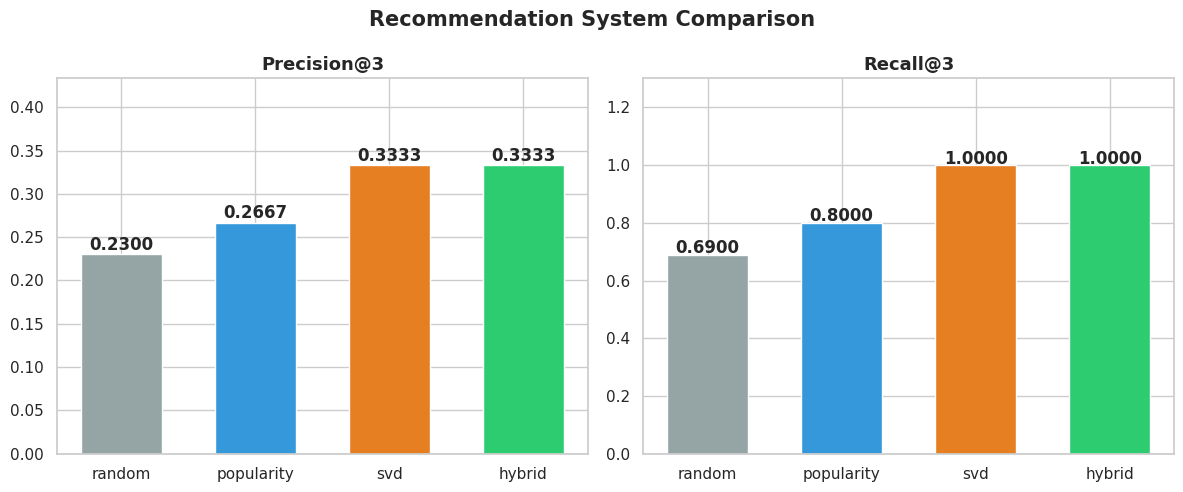

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
methods = list(eval_results.keys())
colors  = ['#95a5a6', '#3498db', '#e67e22', '#2ecc71']

for ax, metric_idx, metric_name in zip(
    axes,
    [0, 1],
    ['Precision@3', 'Recall@3']
):
    values = [list(eval_results[m].values())[metric_idx]
              for m in methods]
    bars   = ax.bar(methods, values, color=colors,
                    edgecolor='white', width=0.6)
    ax.set_title(metric_name, fontweight='bold', fontsize=13)
    ax.set_ylim(0, max(values) * 1.3)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.4f}',
            ha='center', fontweight='bold'
        )

plt.suptitle('Recommendation System Comparison',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/recommendation_evaluation.png', dpi=150)
plt.show()

# **Generate Top-k Recommendations for All At-Risk Customers**

Now we apply our hybrid system to all at-risk customers
and generate their personalized recommendations.

In [13]:
# Generate recommendations for all at-risk customers
at_risk_customers = df[df['is_at_risk'] == 1].index.tolist()
print(f'Generating recommendations for {len(at_risk_customers)} at-risk customers...')

all_recommendations = []
for idx in at_risk_customers:
    customer    = df.iloc[idx]
    reco        = recommend_hybrid(
        idx, df, predicted_ratings,      # ← svd_model remplacé
        service_to_idx, service_matrix, k=3  # ← paramètres ajoutés
    )
    customer_id = customer.get('customerID', f'Customer_{idx}')

    for rank, r in enumerate(reco, 1):
        all_recommendations.append({
            'customer_id':  customer_id,
            'rank':         rank,
            'service':      r['service'],
            'hybrid_score': r['hybrid_score'],
            'churn_score':  r['churn_score'],
            'sentiment':    r['sentiment'],
            'discount':     r['discount']
        })

df_recommendations = pd.DataFrame(all_recommendations)

# Save recommendations
df_recommendations.to_csv(
    'data/processed/recommendations.csv', index=False
)

print(f'\n Recommendations generated : {len(df_recommendations)} total')
print(f'   At-risk customers         : {len(at_risk_customers)}')
print(f'   Average recommendations   : {len(df_recommendations)/len(at_risk_customers):.1f} per customer')
print(f'\nTop 10 recommendations :')
print(df_recommendations.head(10).to_string())

Generating recommendations for 2624 at-risk customers...

 Recommendations generated : 7612 total
   At-risk customers         : 2624
   Average recommendations   : 2.9 per customer

Top 10 recommendations :
  customer_id  rank           service  hybrid_score  churn_score sentiment discount
0  Customer_0     1       StreamingTV        0.6868        0.763  Negative      30%
1  Customer_0     2    OnlineSecurity        0.6820        0.763  Negative      30%
2  Customer_0     3  DeviceProtection        0.6820        0.763  Negative      30%
3  Customer_4     1       StreamingTV        0.7212        0.841  Negative      30%
4  Customer_4     2    OnlineSecurity        0.7204        0.841  Negative      30%
5  Customer_4     3  DeviceProtection        0.7204        0.841  Negative      30%
6  Customer_5     1      OnlineBackup        0.7607        0.921  Negative      30%
7  Customer_5     2       TechSupport        0.7607        0.921  Negative      30%
8  Customer_5     3    OnlineSecurit

## **Analysis — What Does the System Recommend ?**

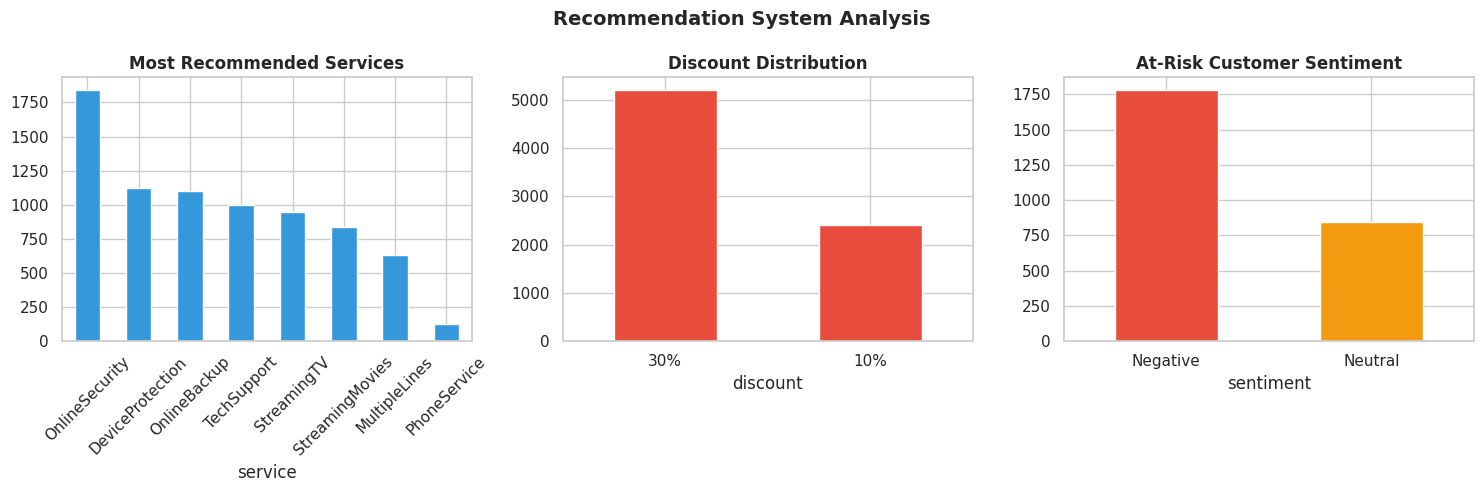

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Most recommended services
df_recommendations['service'].value_counts().plot(
    kind='bar', ax=axes[0],
    color='#3498db', edgecolor='white'
)
axes[0].set_title('Most Recommended Services',
                   fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Discount distribution
df_recommendations['discount'].value_counts().plot(
    kind='bar', ax=axes[1],
    color='#e74c3c', edgecolor='white'
)
axes[1].set_title('Discount Distribution',
                   fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

# Sentiment of at-risk customers
df_at_risk = df[df['is_at_risk'] == 1]
df_at_risk['sentiment'].value_counts().plot(
    kind='bar', ax=axes[2],
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='white'
)
axes[2].set_title('At-Risk Customer Sentiment',
                   fontweight='bold')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Recommendation System Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/recommendation_analysis.png',
            dpi=150)
plt.show()

## **Decision Table — Churn + Sentiment → Action**

This summarizes the business logic of our hybrid system.

In [15]:
print('=' * 65)
print('   HYBRID SYSTEM — DECISION TABLE')
print('=' * 65)
print(f'{"Churn Score":<15} {"Sentiment":<12} {"Action":<25} {"Discount"}')
print('-' * 65)

decision_table = [
    ('> 0.70',   'Negative', 'Urgent — call + top offer', '30%'),
    ('> 0.70',   'Neutral',  'Priority — personalized offer', '20%'),
    ('> 0.70',   'Positive', 'Loyalty offer',              '20%'),
    ('0.40-0.70','Negative', 'Improve experience',         '10%'),
    ('0.40-0.70','Neutral',  'Service upgrade suggestion', '10%'),
    ('0.40-0.70','Positive', 'Loyalty program',            '0%'),
    ('< 0.40',   'Any',      'No action needed',           '0%'),
]

for churn, sent, action, disc in decision_table:
    print(f'{churn:<15} {sent:<12} {action:<25} {disc}')

# Count customers in each category
print('\n=== Customer Distribution ===')
high_risk_neg = df[
    (df['churn_score'] > 0.70) & (df['sentiment'] == 'Negative')
]
high_risk_neu = df[
    (df['churn_score'] > 0.70) & (df['sentiment'] == 'Neutral')
]
mid_risk = df[
    (df['churn_score'] > 0.40) & (df['churn_score'] <= 0.70)
]
low_risk = df[df['churn_score'] <= 0.40]

print(f'High risk + Negative : {len(high_risk_neg):>5} customers → Urgent action')
print(f'High risk + Neutral  : {len(high_risk_neu):>5} customers → Priority action')
print(f'Medium risk          : {len(mid_risk):>5} customers → Monitor')
print(f'Low risk             : {len(low_risk):>5} customers → No action')

   HYBRID SYSTEM — DECISION TABLE
Churn Score     Sentiment    Action                    Discount
-----------------------------------------------------------------
> 0.70          Negative     Urgent — call + top offer 30%
> 0.70          Neutral      Priority — personalized offer 20%
> 0.70          Positive     Loyalty offer             20%
0.40-0.70       Negative     Improve experience        10%
0.40-0.70       Neutral      Service upgrade suggestion 10%
0.40-0.70       Positive     Loyalty program           0%
< 0.40          Any          No action needed          0%

=== Customer Distribution ===
High risk + Negative :  1781 customers → Urgent action
High risk + Neutral  :     0 customers → Priority action
Medium risk          :  1604 customers → Monitor
Low risk             :  3647 customers → No action


# **Save Recommendation System**

We save the SVD model and recommendation functions
for use in Notebook 5 (FastAPI).

In [16]:
# Save SVD matrices
np.save('models/recommendation/predicted_ratings.npy',
        predicted_ratings)
np.save('models/recommendation/U.npy', U)
np.save('models/recommendation/Vt.npy', Vt)
joblib.dump(sigma.tolist(),
            'models/recommendation/sigma.pkl')

# Save service matrix
service_matrix.to_csv(
    'models/recommendation/service_matrix.csv'
)

# Save popularity scores
joblib.dump(popularity,
            'models/recommendation/popularity.pkl')

# Save SERVICES list
joblib.dump(SERVICES,
            'models/recommendation/services_list.pkl')

# Save service_to_idx mapping
joblib.dump(service_to_idx,
            'models/recommendation/service_to_idx.pkl')

print(' Predicted ratings saved')
print(' SVD matrices (U, Sigma, Vt) saved')
print(' Service matrix saved')
print(' Popularity scores saved')
print(' Services list saved')
print(' Service index mapping saved')
print(f'\nFiles in models/recommendation/ :')
for f in os.listdir('models/recommendation'):
    size = os.path.getsize(
        f'models/recommendation/{f}'
    ) / 1024
    print(f'  {f:<40} {size:.1f} KB')

 Predicted ratings saved
 SVD matrices (U, Sigma, Vt) saved
 Service matrix saved
 Popularity scores saved
 Services list saved
 Service index mapping saved

Files in models/recommendation/ :
  predicted_ratings.npy                    439.6 KB
  U.npy                                    384.7 KB
  Vt.npy                                   0.6 KB
  sigma.pkl                                0.1 KB
  service_matrix.csv                       143.2 KB
  popularity.pkl                           0.2 KB
  services_list.pkl                        0.1 KB
  service_to_idx.pkl                       0.2 KB


---
# **Notebook 4 — Complete**

### Results Summary

| Method | Precision@3 | Recall@3 | Note |
|---|---|---|---|
| Random baseline | 0.2300 | 0.6900 | Minimum bar |
| Popularity baseline | 0.2667 | 0.8000 | Simple baseline |
| SVD | 0.3333 | 1.0000 | ML-based |
| **Hybrid (SVD + Churn + Sentiment)** | **0.3333** | **1.0000** | **Our system** |


### What was built
- Client × services matrix from Telco dataset
- User-Based Collaborative Filtering
- Matrix Factorization (SVD) via scipy
- Hybrid score combining churn + sentiment + SVD
- Adaptive discounts based on risk level
- Decision table for business actions

### Key insight
The hybrid system goes beyond simple recommendations :
it combines **WHO is at risk** (churn), **HOW they feel**
(sentiment), and **WHAT they'd like** (SVD) to generate
personalized retention actions.

### What's next
In **Notebook 5**, we expose everything via a
**FastAPI REST API** with 3 endpoints :
- `/predict` → churn score
- `/analyze` → sentiment analysis
- `/recommend` → hybrid recommendations